In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler

In [50]:
df = pd.read_csv('train.csv')

print(df.shape)
df.head()

print(df.columns.tolist())

(104805, 12)
['Id', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [51]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

print(df.isnull().sum())

print(f"\n Distribution of target variable (SeriousDlqin2yrs):")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\n Percentage of defaults: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

 Distribution of target variable (SeriousDlqin2yrs):
SeriousDlqin2yrs
0    97855
1     6950
Name: count, dtype: int64

 Percentage of defaults: 6.63%


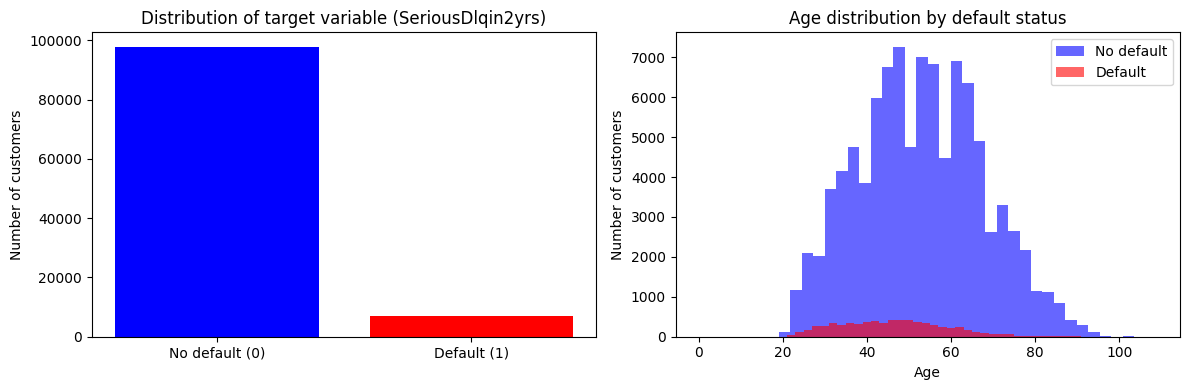

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No default (0)', 'Default (1)'], df['SeriousDlqin2yrs'].value_counts(), color=['blue', 'red'])

axes[0].set_title('Distribution of target variable (SeriousDlqin2yrs)')
axes[0].set_ylabel('Number of customers')

axes[1].hist(df[df['SeriousDlqin2yrs']==0]['age'], bins=40, alpha=0.6, label='No default', color='blue')
axes[1].hist(df[df['SeriousDlqin2yrs']==1]['age'], bins=40, alpha=0.6, label='Default', color='red')
axes[1].set_title('Age distribution by default status')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of customers')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape} clients")
print(f"Test shape: {X_test.shape} clients")

Train shape: (83844, 10) clients
Test shape: (20961, 10) clients


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [56]:
# baseline logistic regression

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred))
print(f'AUC-ROC score: {roc_auc_score(y_test, y_pred_proba):.4f}')

Classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     19637
           1       0.53      0.04      0.07      1324

    accuracy                           0.94     20961
   macro avg       0.74      0.52      0.52     20961
weighted avg       0.91      0.94      0.91     20961

AUC-ROC score: 0.7061


In [57]:
# balanced logistic regression

model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_pred_balanced_proba = model_balanced.predict_proba(X_test_scaled)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred_balanced))
print(f'AUC-ROC score: {roc_auc_score(y_test, y_pred_balanced_proba):.4f}')

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     19637
           1       0.16      0.66      0.26      1324

    accuracy                           0.76     20961
   macro avg       0.57      0.72      0.56     20961
weighted avg       0.92      0.76      0.82     20961

AUC-ROC score: 0.7974


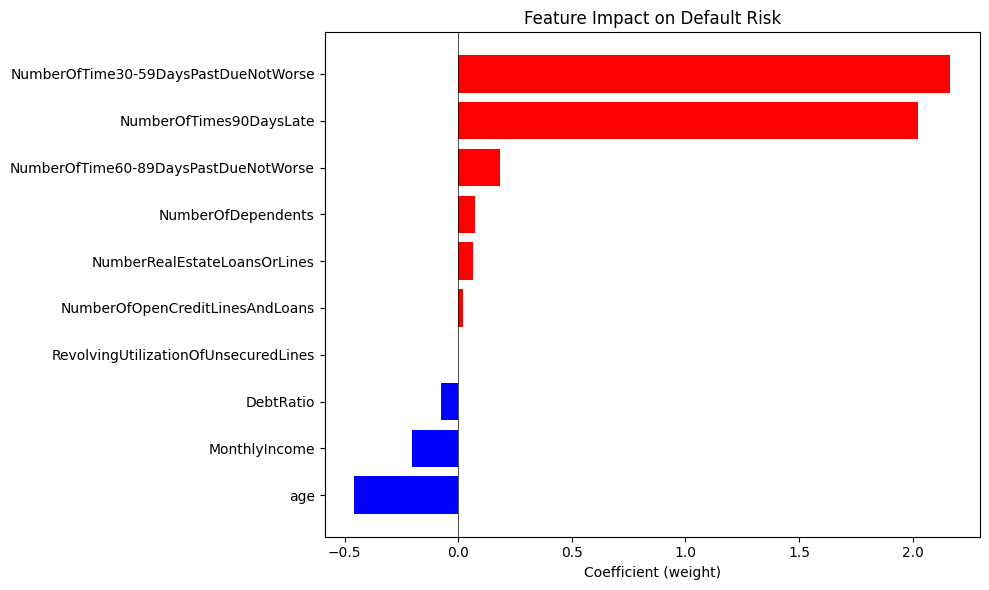

Coefficients:
                             Feature  Coefficient
                                 age    -0.456820
                       MonthlyIncome    -0.202030
                           DebtRatio    -0.075193
RevolvingUtilizationOfUnsecuredLines    -0.001585
     NumberOfOpenCreditLinesAndLoans     0.021356
        NumberRealEstateLoansOrLines     0.064042
                  NumberOfDependents     0.075327
NumberOfTime60-89DaysPastDueNotWorse     0.182677
             NumberOfTimes90DaysLate     2.025115
NumberOfTime30-59DaysPastDueNotWorse     2.165533


In [58]:
# feature importance 

feature_names = X.columns.tolist()
coef = model_balanced.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10,6))
colors = ['red' if c > 0 else 'blue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Feature Impact on Default Risk')
plt.xlabel('Coefficient (weight)')
plt.tight_layout()
plt.show()

print('Coefficients:')
print(coef_df.to_string(index=False))

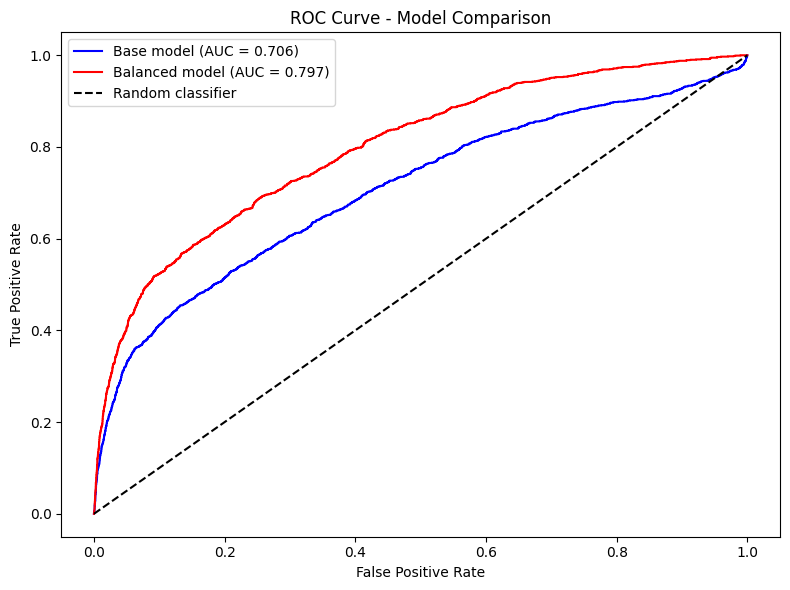

In [59]:
# ROC curves for both models

fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_pred_balanced_proba)

auc_base = roc_auc_score(y_test, y_pred_proba)
auc_bal = roc_auc_score(y_test, y_pred_balanced_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, label=f'Base model (AUC = {auc_base:.3f})', color='blue')
plt.plot(fpr_bal, tpr_bal, label=f'Balanced model (AUC = {auc_bal:.3f})', color='red')
plt.plot([0,1], [0,1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()



In [62]:
print("MODEL COMPARISON SUMMARY")

print(f"{'Metric':<30} {'Base':>10} {'Balanced':>10}")
print(f"{'AUC-ROC':<30} {auc_base:>10.4f} {auc_bal:>10.4f}")
print(f"{'Recall (defaults)':<30} {'4%':>10} {'66%':>10}")
print(f"{'Precision (defaults)':<30} {'53%':>10} {'16%':>10}")
print(f"{'Accuracy':<30} {'94%':>10} {'76%':>10}")
print("\nConclusion:")
print("Balanced model detects 16x more defaults (66% vs 4%)")
print("at the cost of lower precision (16% vs 53%).")
print("In credit risk, high Recall is preferred to avoid")
print("undetected defaults which cause financial losses.")

MODEL COMPARISON SUMMARY
Metric                               Base   Balanced
AUC-ROC                            0.7061     0.7974
Recall (defaults)                      4%        66%
Precision (defaults)                  53%        16%
Accuracy                              94%        76%

Conclusion:
Balanced model detects 16x more defaults (66% vs 4%)
at the cost of lower precision (16% vs 53%).
In credit risk, high Recall is preferred to avoid
undetected defaults which cause financial losses.
